In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/new-plant-diseases-dataset


In [2]:
#base path
train_folder_path="/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_folder_path="/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
test_folder_path="/kaggle/input/new-plant-diseases-dataset/test/test"

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#class names
class_names=os.listdir(train_folder_path)
num_classes=len(os.listdir(train_folder_path))
print("class names: ",class_names)
print("num classes: ",num_classes)

class names:  ['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Strawberry___Leaf_scorch', 'Peach___healthy', 'Apple___Apple_scab', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Apple___Black_rot', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Peach___Bacterial_spot', 'Apple___Cedar_apple_rust', 'Tomato___Target_Spot', 'Pepper,_bell___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Potato___Late_blight', 'Tomato___Tomato_mosaic_virus', 'Strawberry___healthy', 'Apple___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Common_rust_', 'Grape___Esca_(Black_Measles)', 'Raspberry___healthy', 'Tomato___Leaf_Mo

In [5]:
#class distributions
class_distributions={}
for i in class_names:
  class_distributions[i]=len(os.listdir(os.path.join(train_folder_path,i)))
train_class_distribution_df=pd.DataFrame(list(class_distributions.items()),columns=["class","count"])

In [6]:
train_class_distribution_df.head(5)

,class,count
0,Tomato___Late_blight,1851
1,Tomato___healthy,1926
2,Grape___healthy,1692
3,Orange___Haunglongbing_(Citrus_greening),2010
4,Soybean___healthy,2022


/tmp/ipykernel_55/2296401383.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


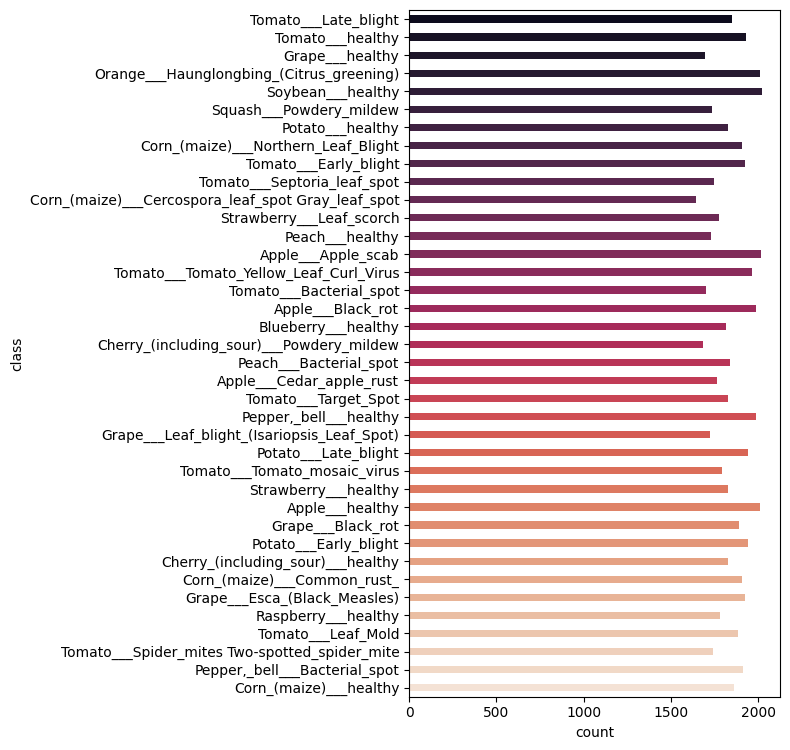

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, len(train_class_distribution_df) * 0.2)) 
sns.barplot(
    x="count",
    y="class",
    data=train_class_distribution_df,
    palette="rocket",
    orient="h",
    width=0.4
)
plt.tight_layout()
plt.show()


In [8]:

#validate class distributions
class_distributions={}
for i in class_names:
  class_distributions[i]=len(os.listdir(os.path.join(valid_folder_path,i)))
validate_class_distribution_df=pd.DataFrame(list(class_distributions.items()),columns=["class","count"])

/tmp/ipykernel_55/984398408.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


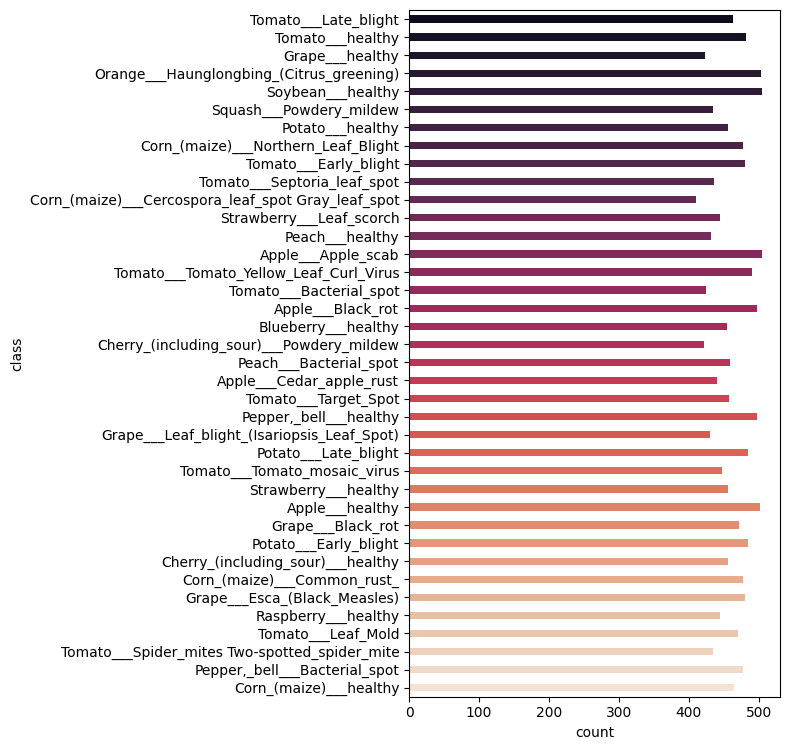

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, len(validate_class_distribution_df) * 0.2)) 
sns.barplot(
    x="count",
    y="class",
    data=validate_class_distribution_df,
    palette="rocket",
    orient="h",
    width=0.4
)
plt.tight_layout()
plt.show()


In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

img_height, img_width = 224, 224
batch_size = 32
num_classes = 38 


train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, 
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_folder_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    valid_folder_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

2026-01-04 10:20:56.328910: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767522056.791219      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767522056.922187      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767522057.979024      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767522057.979070      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767522057.979073      55 computation_placer.cc:177] computation placer alr

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [11]:

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height,img_width,3))
base_model.trainable = False  

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

I0000 00:00:1767522094.888423      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767522094.892346      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)


checkpoint = ModelCheckpoint(
    "best_resnet50_model.h5", 
    monitor='val_accuracy', 
    save_best_only=True, 
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    verbose=1,
    min_lr=1e-6
)

callbacks_list = [early_stop, checkpoint, reduce_lr]


In [14]:
epochs = 10
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=callbacks_list
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1767522107.544373     172 service.cc:152] XLA service 0x7e0ea8001f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767522107.544426     172 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767522107.544434     172 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767522109.595487     172 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/2197 ━━━━━━━━━━━━━━━━━━━━ 9:38:24 16s/step - accuracy: 0.0000e+00 - loss: 4.6482

I0000 00:00:1767522115.666038     172 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1145s 521ms/step - accuracy: 0.8966 - loss: 0.3139 - val_accuracy: 0.9544 - val_loss: 0.1393 - learning_rate: 0.0010
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9083 - loss: 0.2816
Epoch 4: val_accuracy improved from 0.95436 to 0.96107, saving model to best_resnet50_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1130s 514ms/step - accuracy: 0.9083 - loss: 0.2816 - val_accuracy: 0.9611 - val_loss: 0.1197 - learning_rate: 0.0010
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.9113 - loss: 0.2786
Epoch 5: val_accuracy did not improve from 0.96107
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1139s 519ms/step - accuracy: 0.9113 - loss: 0.2786 - val_accuracy: 0.9534 - val_loss: 0.1413 - learning_rate: 0.0010
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.9166 - loss: 0.2576
Epoch 6: val_accuracy improved from 0.96107 to 0.96460, saving model to best_resnet50_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1136s 517ms/step - accuracy: 0.9166 - loss: 0.2576 - val_accuracy: 0.9646 - val_loss: 0.1065 - learning_rate: 0.0010
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.9195 - loss: 0.2467
Epoch 7: val_accuracy improved from 0.96460 to 0.96489, saving model to best_resnet50_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1140s 519ms/step - accuracy: 0.9195 - loss: 0.2467 - val_accuracy: 0.9649 - val_loss: 0.1071 - learning_rate: 0.0010
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9231 - loss: 0.2410
Epoch 8: val_accuracy did not improve from 0.96489
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1126s 512ms/step - accuracy: 0.9231 - loss: 0.2410 - val_accuracy: 0.9646 - val_loss: 0.1085 - learning_rate: 0.0010
Epoch 9/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9252 - loss: 0.2336
Epoch 9: val_accuracy improved from 0.96489 to 0.96904, saving model to best_resnet50_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1116s 508ms/step - accuracy: 0.9252 - loss: 0.2336 - val_accuracy: 0.9690 - val_loss: 0.0925 - learning_rate: 0.0010
Epoch 10/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.9300 - loss: 0.2189
Epoch 10: val_accuracy did not improve from 0.96904
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1120s 510ms/step - accuracy: 0.9300 - loss: 0.2189 - val_accuracy: 0.9688 - val_loss: 0.0957 - learning_rate: 0.0010


# plot the train loss vs val loss

Text(0.5, 1.0, 'epoch vs loss')

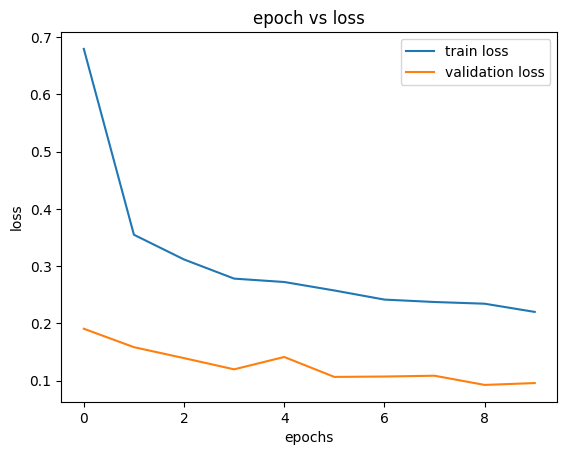

In [40]:
train_loss=history.history['loss']
val_loss=history.history["val_loss"]
plt.plot(train_loss)
plt.plot(val_loss)
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(["train loss","validation loss"])
plt.title("epoch vs loss")

# plot the train accuracy vs val accuracy

Text(0.5, 1.0, 'epoch vs accuracy')

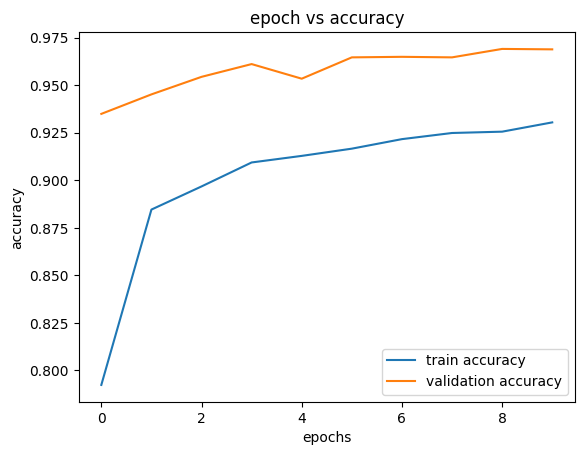

In [41]:
train_loss=history.history['accuracy']
val_loss=history.history["val_accuracy"]
plt.plot(train_loss)
plt.plot(val_loss)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend(["train accuracy","validation accuracy"])
plt.title("epoch vs accuracy")

# confusion matrix

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [44]:
# Reset generator to avoid order issues
val_generator.reset()

# Predict on validation data
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = val_generator.classes

# Class names
class_labels = list(val_generator.class_indices.keys())

550/550 ━━━━━━━━━━━━━━━━━━━━ 64s 107ms/step


In [45]:
print("Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_labels
))


Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.98      0.98       504
                                 Apple___Black_rot       0.99      0.99      0.99       497
                          Apple___Cedar_apple_rust       1.00      1.00      1.00       440
                                   Apple___healthy       0.94      1.00      0.97       502
                               Blueberry___healthy       0.99      1.00      0.99       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.97      0.99       421
                 Cherry_(including_sour)___healthy       0.99      1.00      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.91      0.93       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight     

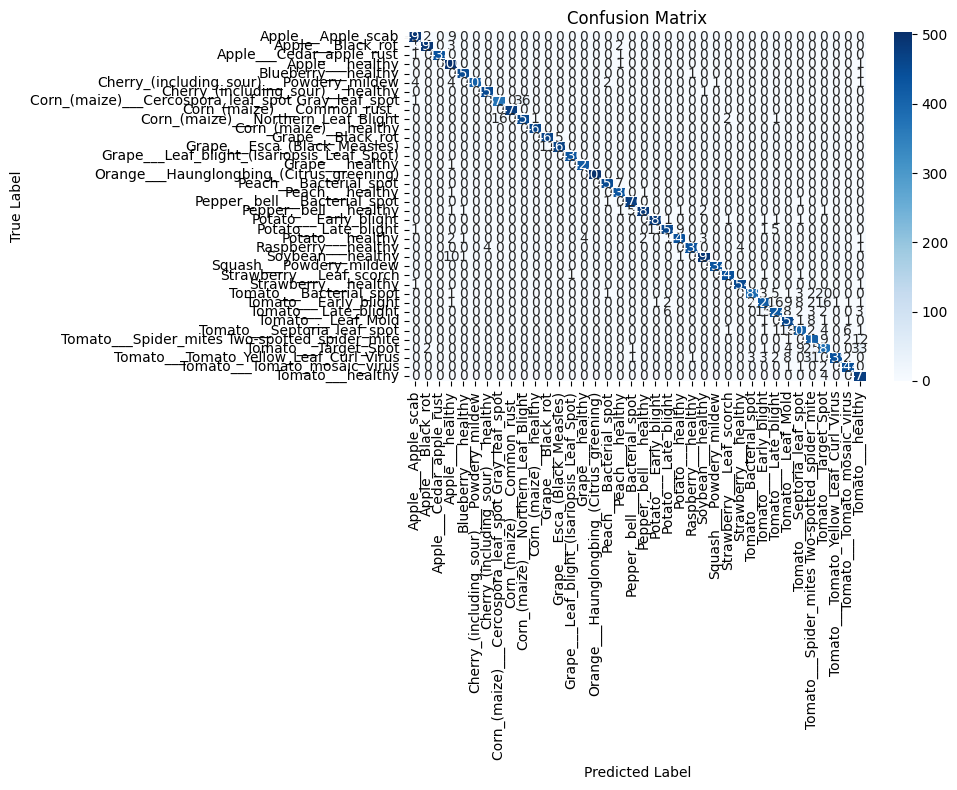

In [46]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [47]:
#overall acccuracy
accuracy = np.mean(y_true == y_pred)
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.9690


In [ ]:
model.save("final_resnet50_model.keras")
import json

# Get class indices from training generator
class_indices = train_generator.class_indices

# Save to file
with open("class_indices.json", "w") as f:
    json.dump(class_indices, f)

print("Class indices saved successfully!")


Class indices saved successfully!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

def predict_and_plot_disease(
    img_path,
    model,
    class_indices,
    img_size=(224, 224)
):
    """
    Predict plant disease and plot image with predicted label and confidence.

    Args:
        img_path (str): Path to image
        model (tf.keras.Model): Trained model
        class_indices (dict): Saved class_indices
        img_size (tuple): Image size (default 224x224)
    """


    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)


    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    confidence = np.max(preds[0])

    # Decode class label
    idx_to_class = {v: k for k, v in class_indices.items()}
    predicted_class = idx_to_class[pred_idx]


    plt.figure(figsize=(6, 6))
    plt.imshow(image.load_img(img_path))
    plt.axis("off")
    plt.title(
        f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}",
        fontsize=14
    )
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


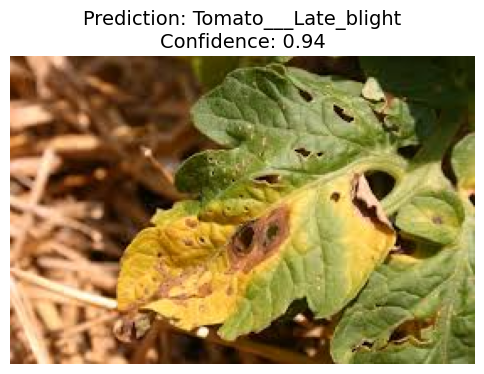

In [54]:
from tensorflow.keras.models import load_model
import json
import warnings 
warnings.filterwarnings("ignore")
# Load model
model = load_model("/kaggle/working/final_resnet50_model.keras")

# Load class indices
with open("/kaggle/working/class_indices.json", "r") as f:
    class_indices = json.load(f)

# Predict & plot
predict_and_plot_disease(
    img_path="/kaggle/input/tomato-disease/tomato_early_blight1.jpg",
    model=model,
    class_indices=class_indices
)
